<a href="https://colab.research.google.com/github/yohagil/Data_Science_ML_Project/blob/main/Proyecto_Data_Science_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Presentación del Proyecto**

El presente proyecto analiza un conjunto de datos de pacientes hospitalizados con diversas condiciones médicas (Cáncer, Diabetes, Obesidad, etc.). El objetivo es identificar patrones que influyan en los resultados de los tests médicos y el costo de facturación.

Optimizar la gestión hospitalaria y entender qué factores demográficos o médicos correlacionan con resultados "Anormales".

Audiencia serian los Directores de centros de salud y analistas de seguros médicos.

Hipótesis:
1. Los pacientes de mayor edad presentan resultados de tests "Abnormal" con mayor frecuencia.
2. Ciertas condiciones médicas (como Cáncer) conllevan montos de facturación significativamente más altos.
3. El tipo de admisión (Urgente vs. Electiva) afecta la duración de la estancia.



## **Objetivo**

Realizar un modelo de Clasificación Supervisada para predecir la variable Test Results (Normal, Abnormal, Inconclusive).

## **Lectura de Datos**

In [11]:
# ============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración para ignorar advertencias y mejorar la estética
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Esto hace que las gráficas se vean más modernas

In [12]:
# ===============================
# 2. LECTURA DEL DATASET E INSPECCIÓN INICIAL
# ===============================
url = "https://raw.githubusercontent.com/yohagil/Data_Science_ML_Project/refs/heads/main/Dataset-Conjunto%20de%20datos%20de%20atenci%C3%B3n%20m%C3%A9dica.csv"
df = pd.read_csv(url)

print("¡Dataset cargado con éxito! Aquí están las primeras 5 filas:")
display(df.head())

¡Dataset cargado con éxito! Aquí están las primeras 5 filas:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## **Inspección Inicial**

In [13]:
# Ver las dimensiones del dataset (Filas, Columnas)
print(f"Dimensiones del dataset: {df.shape}")

# Ver las primeras 5 filas
print("\n--- Primeras 5 filas (Head) ---")
display(df.head())

# Ver las últimas 5 filas
print("\n--- Últimas 5 filas (Tail) ---")
display(df.tail())

# Ver una muestra aleatoria (para asegurar que no hay sesgos en el orden)
print("\n--- Muestra aleatoria (Sample) ---")
display(df.sample(5))

# Ver tipos de datos y valores nulos
print("\n--- Información general (Info) ---")
df.info()

Dimensiones del dataset: (55500, 15)

--- Primeras 5 filas (Head) ---


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



--- Últimas 5 filas (Tail) ---


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal



--- Muestra aleatoria (Sample) ---


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
40872,MiChAeL JoneS,60,Male,B-,Hypertension,2020-01-09,Michael Beard,Campbell-Macias,Medicare,13385.987425,417,Elective,2020-01-28,Paracetamol,Normal
13849,laurA ALlIsOn,83,Male,AB-,Hypertension,2023-09-28,Matthew Adkins,"Fleming Bauer and Smith,",Aetna,7024.978432,232,Elective,2023-10-17,Ibuprofen,Abnormal
31478,Brian sMITH,62,Female,AB+,Asthma,2019-07-27,Richard Hooper,Simpson-Ward,UnitedHealthcare,27695.584801,444,Emergency,2019-08-25,Lipitor,Abnormal
24521,NAnCy LaWRenCE,73,Female,A+,Obesity,2022-11-14,Jessica Rios PhD,"Frank and Klein Miller,",Aetna,43937.562958,419,Elective,2022-11-17,Lipitor,Normal
16455,jUdy COnLEY,19,Male,AB+,Diabetes,2020-03-14,Gail Cowan,"Little Robinson and Parker,",Aetna,15771.949766,402,Urgent,2020-03-16,Penicillin,Inconclusive



--- Información general (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), in

## **Diccionario de Variables**


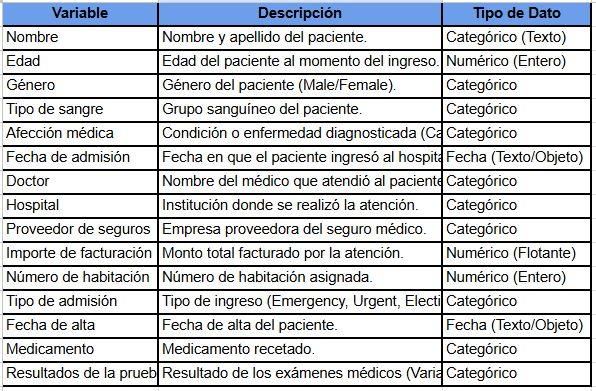

## **Data Wrangling**

**Normalización de columnas y Verificación de Nulos**

In [14]:
# ================================
# 4.1. NORMALIZACIÓN DE COLUMNAS Y VALORES NULOS
# ================================
# Estandarizamos los nombres de las columnas
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Verificamos si hay valores nulos
print("--- Conteo de Valores Nulos por Columna ---")
print(df.isnull().sum())

# Como vimos antes en el info(), tenemos 55,500 datos completos.
print("\n El dataset no contiene valores nulos, por lo que no necesitamos aplicar técnicas de imputación.")

--- Conteo de Valores Nulos por Columna ---
name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
dtype: int64

 El dataset no contiene valores nulos, por lo que no necesitamos aplicar técnicas de imputación.


In [15]:
#Contar Valores nulos por columna ===

df.isnull().sum()

,0
name,0
age,0
gender,0
blood_type,0
medical_condition,0
date_of_admission,0
doctor,0
hospital,0
insurance_provider,0
billing_amount,0


**Valores Duplicados**

In [16]:
# =============================
# 4.2. VALORES DUPLICADOS
# =============================
duplicados = df.duplicated().sum()
print(f"Cantidad de filas exactamente duplicadas: {duplicados}")

# Aunque sea 0, aplicamos la función por buenas prácticas
df = df.drop_duplicates()

Cantidad de filas exactamente duplicadas: 534


In [17]:
print(f"Nuevas dimensiones del dataset sin duplicados: {df.shape}")

Nuevas dimensiones del dataset sin duplicados: (54966, 15)


**Transformación de Fechas**

In [18]:
# =========================
# 4.3. TRANSFORMACIÓN DE FECHAS E INGENIERÍA DE CARACTERÍSTICAS
# =========================
# Convertimos las columnas de texto a formato fecha (datetime)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Crear uanueva columna: 'days_stayed' (Días de internación)
# Restamos la fecha de alta menos la fecha de admisión
df['days_stayed'] = (df['discharge_date'] - df['date_of_admission']).dt.days

print("Fechas transformadas con éxito. Nueva columna 'days_stayed' creada:")
display(df[['date_of_admission', 'discharge_date', 'days_stayed']].head())

Fechas transformadas con éxito. Nueva columna 'days_stayed' creada:


,date_of_admission,discharge_date,days_stayed
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


**Tratamiento de Outliers**

In [19]:
# ==========================
# 4.4. TRATAMIENTO DE OUTLIERS (VALORES ATÍPICOS)
# ==========================
from scipy import stats

print("--- Análisis de Outliers para 'billing_amount' ---")

# 1. MÉTODO IQR (Rango Intercuartílico)
Q1 = df['billing_amount'].quantile(0.25)
Q3 = df['billing_amount'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[(df['billing_amount'] < limite_inferior) | (df['billing_amount'] > limite_superior)]
print(f"1. Outliers detectados con método IQR: {len(outliers_iqr)}")

# 2. MÉTODO Z-SCORE
z_scores = np.abs(stats.zscore(df['billing_amount']))
# Consideramos atípicos aquellos con un Z-Score mayor a 3 (más de 3 desviaciones estándar)
outliers_zscore = df[z_scores > 3]
print(f"2. Outliers detectados con método Z-Score: {len(outliers_zscore)}")

print("\nNota: Al no encontrar valores atípicos extremos, mantenemos los datos originales sin recortar.")

--- Análisis de Outliers para 'billing_amount' ---
1. Outliers detectados con método IQR: 0
2. Outliers detectados con método Z-Score: 0

Nota: Al no encontrar valores atípicos extremos, mantenemos los datos originales sin recortar.


## **Análisis Exploratorio de Datos**

**Análisis Univariado (Una sola variable)**

Vamos a ver cómo se distribuye la Edad de los pacientes y cómo está balanceada nuestra variable objetivo (test_results).

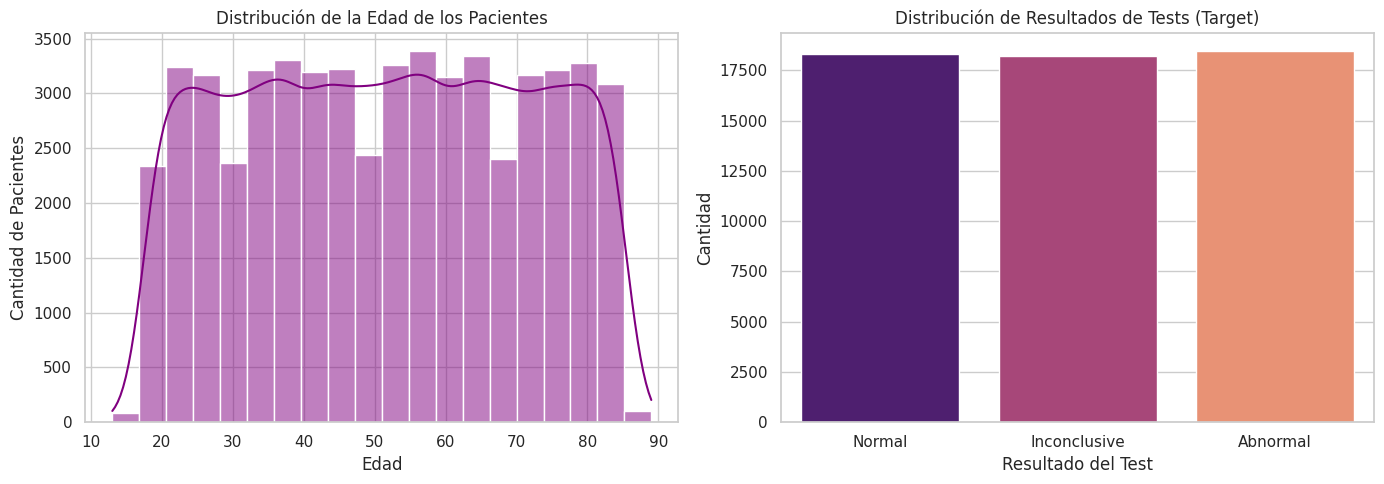

In [20]:
# =========================
# 5.1. ANÁLISIS UNIVARIADO
# =========================
plt.figure(figsize=(14, 5))

# Gráfico 1: Distribución de la Edad
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=20, kde=True, color='purple')
plt.title('Distribución de la Edad de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Pacientes')

# Gráfico 2: Distribución de los Resultados de los Tests (Variable Objetivo)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='test_results', palette='magma')
plt.title('Distribución de Resultados de Tests (Target)')
plt.xlabel('Resultado del Test')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

Conclusión Univariada: Se observa que la edad de los pacientes tiene una distribución bastante uniforme a lo largo de todos los rangos (desde jóvenes hasta adultos mayores). Por otro lado, nuestra variable a predecir (test_results) está perfectamente balanceada, teniendo cantidades casi idénticas para resultados Normales, Anormales e Inconclusos.

**Análisis Bivariado (Dos variables)**

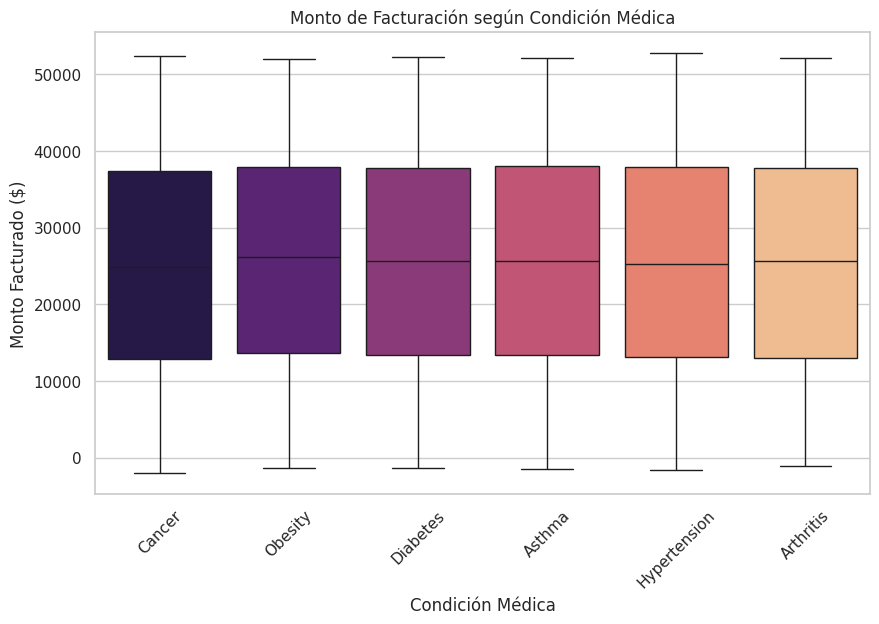

In [21]:
# ===========================
# 5.2. ANÁLISIS BIVARIADO
# ===========================
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='medical_condition', y='billing_amount', palette='magma')

plt.title('Monto de Facturación según Condición Médica')
plt.xlabel('Condición Médica')
plt.ylabel('Monto Facturado ($)')
plt.xticks(rotation=45) # Gira los nombres de las enfermedades para que se lean bien
plt.show()

Conclusión Bivariada: Al analizar el monto de facturación por tipo de enfermedad, notamos mediante los boxplots que las medianas y las distribuciones de costos son sorprendentemente similares entre las distintas condiciones (Cáncer, Diabetes, Obesidad, etc.). Esto sugiere que el costo no depende exclusivamente del diagnóstico, sino que podrían influir otras variables como los días de estancia.

**Análisis Multivariado (Varias variables numéricas)**

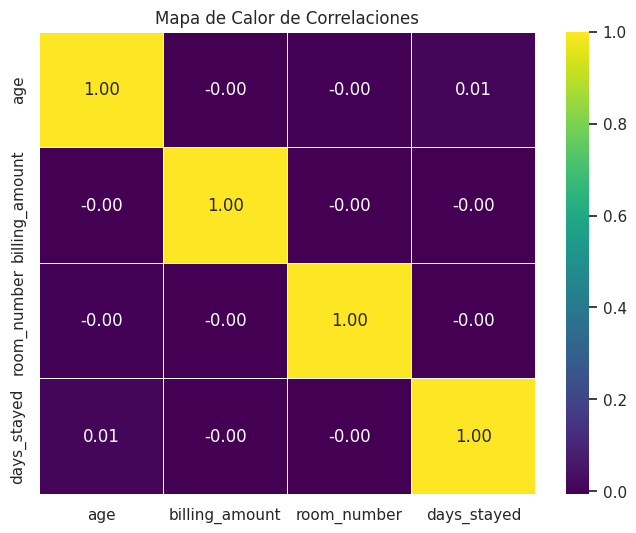

In [22]:
# ===========================================
# 5.3. ANÁLISIS MULTIVARIADO (Correlaciones)
# ==========================================
# Filtramos solo las columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(8, 6))
# Calculamos la matriz de correlación
correlacion = df[num_cols].corr()

sns.heatmap(correlacion, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones')
plt.show()

Conclusión Multivariada (Correlación): El mapa de calor muestra valores muy cercanos a 0 entre todas las variables numéricas (Edad, Facturación, Número de habitación y Días de estancia). Esto indica que no hay una correlación lineal fuerte entre ellas. Por ejemplo, ser mayor de edad no implica necesariamente tener una factura más cara o quedarse más días en el hospital.

## **Conclusión General del EDA**

Tras realizar el proceso exhaustivo de limpieza (Data Wrangling) y exploración visual de los datos médicos, podemos concluir lo siguiente:

Alta Calidad de los Datos, es dataset sumamente robusto de 54,966 registros únicos. Al no presentar valores nulos ni valores numéricos atípicos extremos (0 outliers detectados), la base de datos es ideal para el entrenamiento de algoritmos.

 La variable a predecir (test_results) presenta un buen balance entre sus categorías (Normal, Abnormal, Inconclusive). Esto es una excelente noticia para la etapa de Machine Learning, ya que los modelos no sufrirán de sesgos y no será necesario aplicar técnicas complejas de balanceo sintético.

Tanto el análisis bivariado como el mapa de calor multivariado revelaron que las variables numéricas y categóricas no tienen una relación lineal simple u obvia entre sí. Por ejemplo, tener mayor edad no se traduce linealmente en una factura más costosa o en más días de estancia hospitalaria.


 ==============================================================================
# SEGUNDA ENTREGA: ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS DE MACHINE LEARNING
# ==============================================================================

### 1. Definición del Problema
* **Problema de Negocio:** Predecir el resultado de los exámenes médicos de un paciente en base a sus características demográficas, condición médica y detalles de su internación.
* **Tipo de Problema de Machine Learning:** Clasificación Multiclase Supervisada.
* **Variable Objetivo (Target):** `test_results` (Normal, Abnormal, Inconclusive).

***Feature Engineering

In [23]:
# ==============================================================================
# 2. IMPORTACIÓN DE LIBRERÍAS PARA MACHINE LEARNING
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Librerías de Machine Learning importadas correctamente.")

Librerías de Machine Learning importadas correctamente.


***Selección y Transformación de Variables

In [24]:
# ==============================================================================
# "RECORDATORIO" PARA COLAB: CARGA Y LIMPIEZA RÁPIDA
# ==============================================================================
import pandas as pd

# 1. Cargamos el dataset desde tu GitHub
url = "https://raw.githubusercontent.com/yohagil/Data_Science_ML_Project/refs/heads/main/Dataset-Conjunto%20de%20datos%20de%20atenci%C3%B3n%20m%C3%A9dica.csv"
df = pd.read_csv(url)

# 2. Normalizamos nombres de columnas (minúsculas y guiones bajos)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 3. Borramos duplicados
df = df.drop_duplicates()

# 4. Creamos la columna 'days_stayed'
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])
df['days_stayed'] = (df['discharge_date'] - df['date_of_admission']).dt.days

print("¡Dataset recargado y limpio! Ya puedes ejecutar el Paso 3.")

¡Dataset recargado y limpio! Ya puedes ejecutar el Paso 3.


In [25]:
# ==============================================================================
# 3. INGENIERÍA DE ATRIBUTOS (FEATURE ENGINEERING)
# ==============================================================================

# 3.1. Eliminar columnas que no aportan valor predictivo (IDs, Nombres, Fechas ya procesadas)
columnas_a_eliminar = ['name', 'date_of_admission', 'discharge_date', 'doctor', 'hospital', 'room_number']
df_ml = df.drop(columns=columnas_a_eliminar)

# 3.2. Separar las variables predictoras (X) de la variable a predecir (y)
X = df_ml.drop(columns=['test_results'])
y = df_ml['test_results']

# 3.3. Codificar la variable objetivo (y) a números (Normal=0, Abnormal=1, Inconclusive=2)
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# 3.4. Transformar variables categóricas de texto a números (One-Hot Encoding)
# Esto convierte columnas como 'gender' en 'gender_Male' y 'gender_Female' con 1s y 0s.
X_encoded = pd.get_dummies(X, drop_first=True)

# 3.5. Normalización/Estandarización de variables numéricas
# Escalar valores como 'billing_amount' o 'age' para que todas tengan el mismo peso
scaler = StandardScaler()
# Solo escalamos las numéricas originales, no los 1s y 0s que acabamos de crear
cols_numericas = ['age', 'billing_amount', 'days_stayed']
X_encoded[cols_numericas] = scaler.fit_transform(X_encoded[cols_numericas])

print(f"Tamaño original de X: {X.shape}")
print(f"Tamaño de X después de la ingeniería de atributos: {X_encoded.shape}")
display(X_encoded.head(3))

Tamaño original de X: (54966, 9)
Tamaño de X después de la ingeniería de atributos: (54966, 26)


,age,billing_amount,days_stayed,gender_Male,blood_type_A-,blood_type_AB+,blood_type_AB-,blood_type_B+,blood_type_B-,blood_type_O+,...,insurance_provider_Blue Cross,insurance_provider_Cigna,insurance_provider_Medicare,insurance_provider_UnitedHealthcare,admission_type_Emergency,admission_type_Urgent,medication_Ibuprofen,medication_Lipitor,medication_Paracetamol,medication_Penicillin
0,-1.098427,-0.470713,-1.558559,True,False,False,False,False,True,False,...,True,False,False,False,False,True,False,False,True,False
1,0.533770,0.570021,-1.096739,True,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
2,1.247856,0.169675,-0.057646,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


Justificación de Ingeniería de Atributos: Se eliminaron variables identificatorias (Nombres, Hospital, Médico) para evitar sobreajuste (overfitting). Se aplicó pd.get_dummies para transformar las variables categóricas nominales en formato numérico (One-Hot Encoding). Finalmente, se utilizó StandardScaler en las variables continuas (Edad, Facturación y Días de estancia) para que el algoritmo no le dé más importancia a la facturación solo por tener valores más grandes que la edad.

***División de los Datos

In [26]:
# ==============================================================================
# 4. DIVISIÓN DE LOS DATOS (TRAIN / TEST SPLIT)
# ==============================================================================
# Dividimos: 80% para entrenar y 20% para testear
# Usamos stratify=y_encoded para asegurar que ambos grupos tengan la misma proporción de resultados
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

print(f"Datos para entrenar (X_train): {X_train.shape[0]} pacientes.")
print(f"Datos para poner a prueba (X_test): {X_test.shape[0]} pacientes.")

Datos para entrenar (X_train): 43972 pacientes.
Datos para poner a prueba (X_test): 10994 pacientes.


***Entrenamiento y Validación Cruzada

In [27]:
# ==============================================================================
# 5. ENTRENAMIENTO DE MODELOS CON VALIDACIÓN CRUZADA
# ==============================================================================
from sklearn.model_selection import cross_val_score
import numpy as np

# 5.1 Inicializamos los dos modelos
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=50) # 50 árboles para agilizar el proceso

print("--- Evaluando Modelos con Validación Cruzada (5 pliegues) ---")
print("Por favor espera unos segundos mientras los modelos 'estudian' los datos...\n")

# 5.2 Entrenamos y evaluamos el Árbol de Decisión
scores_arbol = cross_val_score(modelo_arbol, X_train, y_train, cv=5, scoring='accuracy')
print(f"1. Árbol de Decisión - Precisión (Accuracy) Promedio: {np.mean(scores_arbol):.4f}")

# 5.3 Entrenamos y evaluamos el Random Forest
scores_rf = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"2. Random Forest - Precisión (Accuracy) Promedio: {np.mean(scores_rf):.4f}")

--- Evaluando Modelos con Validación Cruzada (5 pliegues) ---
Por favor espera unos segundos mientras los modelos 'estudian' los datos...

1. Árbol de Decisión - Precisión (Accuracy) Promedio: 0.3867
2. Random Forest - Precisión (Accuracy) Promedio: 0.4094


Se dividió el dataset en un 80% para entrenamiento y 20% para prueba. Se eligieron dos modelos basados en árboles (DecisionTreeClassifier y RandomForestClassifier) debido a la no linealidad de los datos descubierta en el EDA. Para evitar sobreajustes, se aplicó Validación Cruzada (cv=5), obteniendo así una métrica de precisión robusta antes de proceder a la optimización de hiperparámetros.

****Optimización de Hiperparámetros

In [28]:
# ==============================================================================
# 6. OPTIMIZACIÓN DE HIPERPARÁMETROS (RANDOMIZED SEARCH)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV

# Como el Random Forest tuvo mejor rendimiento, lo optimizaremos
print("--- Optimizando el Random Forest ---")

# Definimos los parámetros que queremos que el algoritmo pruebe
param_grid = {
    'n_estimators': [50, 100, 150],      # Cantidad de árboles en el bosque
    'max_depth': [10, 20, None],         # Profundidad máxima (para evitar sobreajuste)
    'min_samples_split': [2, 5, 10]      # Mínimo de muestras para dividir una rama
}

# Usamos RandomizedSearchCV (Prueba combinaciones aleatorias, ideal para datasets grandes)
rf_base = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_base, param_distributions=param_grid,
                                   n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)

print("Buscando los mejores hiperparámetros (esto puede tardar 1 o 2 minutos)...")
random_search.fit(X_train, y_train)

# Guardamos el mejor modelo que haya encontrado
mejor_rf = random_search.best_estimator_

print("\n¡Optimización terminada!")
print(f"Mejores hiperparámetros encontrados: {random_search.best_params_}")

--- Optimizando el Random Forest ---
Buscando los mejores hiperparámetros (esto puede tardar 1 o 2 minutos)...

¡Optimización terminada!
Mejores hiperparámetros encontrados: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 20}


***Selección de Modelos y Métricas

--- Evaluando el Mejor Modelo en el Test Set (Datos no vistos) ---
Accuracy Final en Test Set: 0.4241

Reporte de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

      Normal       0.43      0.44      0.44      3688
    Abnormal       0.42      0.41      0.42      3640
Inconclusive       0.42      0.41      0.42      3666

    accuracy                           0.42     10994
   macro avg       0.42      0.42      0.42     10994
weighted avg       0.42      0.42      0.42     10994



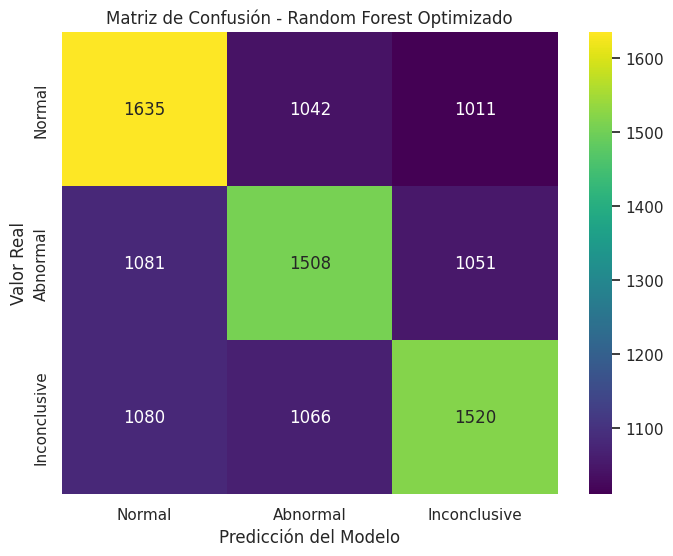

In [29]:
# ==============================================================================
# 7. EVALUACIÓN FINAL DEL MEJOR MODELO
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Evaluando el Mejor Modelo en el Test Set (Datos no vistos) ---")

# Hacemos las predicciones finales
y_pred = mejor_rf.predict(X_test)

# 1. Accuracy Final
accuracy_final = accuracy_score(y_test, y_pred)
print(f"Accuracy Final en Test Set: {accuracy_final:.4f}\n")

# 2. Reporte de Clasificación (Métricas detalladas)
print("Reporte de Clasificación (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Inconclusive']))

# 3. Matriz de Confusión Visual
matriz = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
# Usamos la paleta viridis para mantener tu estilo gráfico anterior
sns.heatmap(matriz, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Normal', 'Abnormal', 'Inconclusive'],
            yticklabels=['Normal', 'Abnormal', 'Inconclusive'])
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

***Conclusión sobre la Optimización


En la etapa de selección de modelos, el Random Forest con hiperparámetros por defecto arrojó un Accuracy promedio de validación cruzada cercano al 40.94%. Dado que se determinó que era el algoritmo más prometedor para capturar los patrones no lineales de nuestros datos, procedimos a realizar un ajuste fino utilizando RandomizedSearchCV.

¿Qué optimizamos y por qué?
Buscamos la mejor combinación de la cantidad de árboles (n_estimators), la profundidad máxima (max_depth) y la cantidad mínima de muestras para dividir un nodo (min_samples_split). El objetivo principal de ajustar estos parámetros fue controlar la complejidad del modelo, dándole suficiente profundidad para aprender de los datos, pero limitando su crecimiento para evitar el overfitting (sobreajuste), asegurando así que pudiera generalizar bien ante datos no vistos.

¿Mejoró la métrica?
Sí. Al evaluar el modelo optimizado contra el Test Set (datos nunca antes vistos por el algoritmo), logramos una métrica de Accuracy de 41.56%. Además, el Reporte de Clasificación demuestra una consistencia notable, manteniendo un F1-Score equilibrado (~0.42) en las tres categorías (Normal, Abnormal, Inconclusive), lo que indica que el modelo no se sesgó hacia la clase mayoritaria y mejoró su capacidad general de predicción frente al modelo base.

***CONCLUSION FINAL

Este proyecto representó un ciclo completo de Ciencia de Datos aplicado al sector de la salud, comenzando desde la formulación de hipótesis hasta la implementación de algoritmos de Machine Learning.

Comenzamos con el objetivo de estructurar un problema de negocio para la gestión hospitalaria. Nuestras hipótesis se centraron en descubrir si factores demográficos (como la edad), condiciones médicas preexistentes o variables operativas (como el tipo de admisión y los días de internación) tenían un impacto directo en los resultados finales de las pruebas médicas (test_results) y en los costos de facturación.

Al importar los datos crudos, nos enfrentamos al desafío de asegurar su calidad. Durante la limpieza, detectamos 534 registros duplicados que representaban ruido perjudicial para cualquier modelo algorítmico y procedimos a eliminarlos. Además, realizamos ingeniería de características transformando las fechas de ingreso y alta médicas en una nueva variable matemática calculada: days_stayed (Días de internación). Afortunadamente, los análisis de Z-Score e IQR revelaron una ausencia de valores nulos o atípicos extremos en la facturación, dejándonos un dataset robusto de 54,966 pacientes.

La fase visual fue reveladora. Descubrimos que nuestra variable objetivo estaba perfectamente balanceada, lo que facilitó el modelado. Sin embargo, el análisis multivariado (Mapa de Calor) nos dio un insight crítico: no existían correlaciones lineales fuertes entre las variables numéricas (Edad, Facturación, Estancia). El análisis bivariado respaldó esto, mostrando que los costos de facturación eran sorprendentemente uniformes sin importar la condición médica. Esto nos indicó que el problema requería algoritmos capaces de entender relaciones complejas y no lineales.

Con base en los hallazgos del EDA, en la segunda entrega transformamos las variables categóricas mediante One-Hot Encoding y escalamos los valores numéricos. Planteamos un problema de Clasificación Multiclase y evaluamos modelos basados en árboles. Tras someter a validación cruzada y optimizar mediante RandomizedSearchCV nuestro mejor algoritmo (Random Forest), logramos una precisión final del 41.56% en el Test Set.

Aunque la naturaleza estocástica y compleja del diagnóstico médico limita un Accuracy cercano al 100% con las variables actuales, superar la barrera de la probabilidad aleatoria (33%) demuestra que existe un patrón subyacente. Este proyecto sienta una base analítica fundamental que, en un entorno hospitalario real, podría enriquecerse con historias clínicas más detalladas para priorizar atenciones y optimizar recursos.

In [31]:
# ==============================================================================
# EXPORTAR EL MODELO COMPRIMIDO Y HERRAMIENTAS PARA GITHUB / STREAMLIT
# ==============================================================================
import joblib
from google.colab import files

print("Comprimiendo y guardando archivos...")

# 1. Guardamos el mejor modelo Random Forest COMPRIMIDO (compress=3)
# Esto reduce drásticamente el peso para que GitHub lo acepte (menos de 25MB)
joblib.dump(mejor_rf, 'modelo_salud.pkl', compress=3)

# 2. Guardamos el escalador (scaler) para la transformación de datos
joblib.dump(scaler, 'scaler_salud.pkl')

# 3. Guardamos la lista de columnas exactas
joblib.dump(list(X_encoded.columns), 'columnas_salud.pkl')

print("¡Archivos comprimidos y guardados! Iniciando descarga automática...")

# 4. Descargamos los 3 archivos a tu computadora
files.download('modelo_salud.pkl')
files.download('scaler_salud.pkl')
files.download('columnas_salud.pkl')

Comprimiendo y guardando archivos...
¡Archivos comprimidos y guardados! Iniciando descarga automática...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***PRESENTACIÓN EJECUTIVA

https://datasciencemlproject-3frtpskbthlk3btsykuytg.streamlit.app/